# 🏥 ENTREGA 3 - MODELADO Y ANÁLISIS DE RESULTADOS

## **Predicción de Supervivencia Hospitalaria UCI**

---

## 📋 CONTENIDO

1. **Introducción y Carga de Datos**
2. **¿Qué Modelos Elegimos y Por Qué?**
3. **¿Qué Significan los Parámetros?**
4. **Entrenamiento de Modelos**
5. **¿Cómo Evaluamos? - Explicación de Métricas**
6. **Comparación Visual y Justificación del Ganador**
7. **Patrones Identificados**
8. **Interpretación y Aplicación Práctica**
9. **Conclusiones**

## 1️⃣ INTRODUCCIÓN Y CARGA DE DATOS

In [1]:
# Imports necesarios
import sys
import os

# Agregar path del proyecto
sys.path.append('../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Librerías cargadas correctamente")
print("📁 Ruta del proyecto configurada")

# Mostrar título bonito
display(HTML("""
<div style='background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            padding: 30px; border-radius: 15px; text-align: center; margin: 20px 0;'>
    <h1 style='color: white; font-size: 42px; margin: 0; text-shadow: 2px 2px 4px rgba(0,0,0,0.3);'>
        📊 CARGA DE DATOS
    </h1>
</div>
"""))

✅ Librerías cargadas correctamente
📁 Ruta del proyecto configurada


In [ ]:
# Cargar dataset LIMPIO (generado en Entrega 2)
dataset_path = '../PRESENTACION/dataset_clean_final.csv'

print("📂 Cargando dataset limpio...")
df = pd.read_csv(dataset_path)

# Variable objetivo
mortality_rate = df['hospital_death'].mean() * 100
survivors = (df['hospital_death'] == 0).sum()
deaths = (df['hospital_death'] == 1).sum()

display(HTML(f"""
<div style='display: grid; grid-template-columns: repeat(3, 1fr); gap: 20px; margin: 30px 0;'>
    <div style='background: linear-gradient(135deg, #3498db 0%, #2980b9 100%);
                padding: 25px; border-radius: 12px; color: white; box-shadow: 0 4px 6px rgba(0,0,0,0.1);'>
        <div style='font-size: 16px; font-weight: bold; margin-bottom: 8px;'>📈 PACIENTES</div>
        <div style='font-size: 42px; font-weight: bold; margin: 10px 0;'>{df.shape[0]:,}</div>
        <div style='font-size: 16px;'>Filas del dataset</div>
    </div>
    
    <div style='background: linear-gradient(135deg, #27ae60 0%, #229954 100%);
                padding: 25px; border-radius: 12px; color: white; box-shadow: 0 4px 6px rgba(0,0,0,0.1);'>
        <div style='font-size: 16px; font-weight: bold; margin-bottom: 8px;'>✅ SUPERVIVIENTES</div>
        <div style='font-size: 42px; font-weight: bold; margin: 10px 0;'>{survivors:,}</div>
        <div style='font-size: 16px;'>{100-mortality_rate:.1f}% del total</div>
    </div>
    
    <div style='background: linear-gradient(135deg, #e74c3c 0%, #c0392b 100%);
                padding: 25px; border-radius: 12px; color: white; box-shadow: 0 4px 6px rgba(0,0,0,0.1);'>
        <div style='font-size: 16px; font-weight: bold; margin-bottom: 8px;'>⚠️ FALLECIMIENTOS</div>
        <div style='font-size: 42px; font-weight: bold; margin: 10px 0;'>{deaths:,}</div>
        <div style='font-size: 16px;'>{mortality_rate:.1f}% del total</div>
    </div>
</div>
"""))

print("\n⚠️ DESBALANCE IMPORTANTE:")
print(f"   • Por cada paciente que muere, hay {survivors/deaths:.1f} que sobreviven")
print(f"   • Esto hace que la métrica 'Accuracy' NO sea suficiente")
print(f"   • Necesitamos métricas especializadas para datos desbalanceados")

## 2️⃣ SELECCIÓN DE ALGORITMOS Y JUSTIFICACIÓN

### **¿Por qué elegimos estos 2 algoritmos?**

Para este problema de clasificación binaria (supervivencia vs muerte) con datos médicos, seleccionamos:

---

### **MODELO 1: Random Forest (Bosque Aleatorio)**

**Tipo:** Ensemble de árboles de decisión

**Justificación:**
1. ✅ **Robusto ante outliers** - Los datos médicos tienen valores extremos (pacientes críticos)
2. ✅ **No requiere escalado** - Las variables están en diferentes escalas (edad, presión, temperatura)
3. ✅ **Captura relaciones no lineales** - Las interacciones médicas no son lineales
4. ✅ **Proporciona importancia de variables** - Crucial para interpretación médica
5. ✅ **Maneja desbalance de clases** - Con `class_weight='balanced'`

**Características:**
- Construye múltiples árboles de decisión independientes
- Cada árbol vota y la mayoría decide la predicción final
- Reduce overfitting comparado con un árbol único

---

### **MODELO 2: XGBoost (Extreme Gradient Boosting)**

**Tipo:** Gradient Boosting optimizado

**Justificación:**
1. ✅ **Alta precisión** - Uno de los algoritmos más potentes para clasificación
2. ✅ **Regularización incorporada** - Evita overfitting con L1/L2 regularization
3. ✅ **Manejo eficiente de desbalance** - Con `scale_pos_weight`
4. ✅ **Aprendizaje gradual** - Corrige errores de iteraciones anteriores
5. ✅ **Optimizado computacionalmente** - Entrenamiento rápido y eficiente

**Características:**
- Construye árboles secuencialmente (no en paralelo como Random Forest)
- Cada nuevo árbol corrige errores del anterior
- Utiliza técnicas avanzadas de optimización

---

### **Diferencias principales:**

| Aspecto | Random Forest | XGBoost |
|---------|--------------|----------|
| **Construcción** | Árboles independientes (paralelizable) | Árboles secuenciales (boosting) |
| **Objetivo** | Reducir varianza (bagging) | Reducir sesgo (boosting) |
| **Velocidad** | Más rápido | Más lento pero optimizado |
| **Precisión** | Alta | Muy alta |
| **Interpretabilidad** | Buena | Buena |
| **Riesgo overfitting** | Bajo | Medio (controlado con regularización) |

## 3️⃣ DEFINICIÓN Y JUSTIFICACIÓN DE PARÁMETROS

### **PARÁMETROS DE RANDOM FOREST**

```python
RandomForestClassifier(
    n_estimators=200,         # Número de árboles
    max_depth=15,             # Profundidad máxima
    min_samples_split=10,     # Mínimo para dividir nodo
    min_samples_leaf=5,       # Mínimo en hoja
    max_features='sqrt',      # Features por split
    class_weight='balanced',  # Balanceo de clases
    random_state=42           # Reproducibilidad
)
```

**Justificación de cada parámetro:**

1. **`n_estimators=200`**
   - ¿Qué hace? Número de árboles en el bosque
   - ¿Por qué 200? Balance entre precisión y tiempo de cómputo
   - Más árboles = mejor generalización (hasta cierto punto)

2. **`max_depth=15`**
   - ¿Qué hace? Profundidad máxima de cada árbol
   - ¿Por qué 15? Evita overfitting mientras permite capturar complejidad
   - Profundidades >20 tienden a memorizar datos de entrenamiento

3. **`min_samples_split=10`**
   - ¿Qué hace? Mínimo de muestras para dividir un nodo
   - ¿Por qué 10? Evita splits en grupos muy pequeños (reduce overfitting)
   - Con 91,713 pacientes, 10 es un umbral razonable

4. **`min_samples_leaf=5`**
   - ¿Qué hace? Mínimo de muestras en cada hoja terminal
   - ¿Por qué 5? Asegura decisiones basadas en suficientes casos
   - Hojas muy pequeñas = reglas poco confiables

5. **`max_features='sqrt'`**
   - ¿Qué hace? Número de features consideradas en cada split
   - ¿Por qué sqrt? Reduce correlación entre árboles (mejora ensemble)
   - Con ~80 features → sqrt(80) ≈ 9 features por split

6. **`class_weight='balanced'`**
   - ¿Qué hace? Ajusta pesos para balancear clases desbalanceadas
   - ¿Por qué? Tenemos 91% sobrevive vs 9% muere
   - Evita que el modelo solo prediga "sobrevive"

---

### **PARÁMETROS DE XGBOOST**

```python
XGBClassifier(
    n_estimators=200,              # Boosting rounds
    max_depth=6,                   # Profundidad de árboles
    learning_rate=0.05,            # Tasa de aprendizaje
    subsample=0.8,                 # Muestras por árbol
    colsample_bytree=0.8,          # Features por árbol
    gamma=1,                       # Regularización de split
    reg_alpha=0.1,                 # Regularización L1
    reg_lambda=1,                  # Regularización L2
    scale_pos_weight=ratio,        # Balanceo automático
    random_state=42
)
```

**Justificación de cada parámetro:**

1. **`n_estimators=200`**
   - Igual que Random Forest, 200 boosting rounds
   - Más rounds = mejor ajuste (pero riesgo de overfitting)

2. **`max_depth=6`**
   - Menor que RF porque boosting es más propenso a overfit
   - Árboles más superficiales + más iteraciones = mejor generalización

3. **`learning_rate=0.05`**
   - ¿Qué hace? Peso de cada árbol en la predicción final
   - ¿Por qué 0.05? Learning rate bajo = aprendizaje gradual
   - Valores bajos requieren más árboles pero generalizan mejor

4. **`subsample=0.8`**
   - ¿Qué hace? Porcentaje de muestras usadas por árbol
   - ¿Por qué 0.8? Introduce aleatoriedad (reduce overfitting)
   - Similar a bootstrapping de Random Forest

5. **`colsample_bytree=0.8`**
   - ¿Qué hace? Porcentaje de features por árbol
   - ¿Por qué 0.8? Reduce correlación entre árboles
   - 80% de 80 features = ~64 features por árbol

6. **`gamma=1`**
   - ¿Qué hace? Ganancia mínima requerida para hacer un split
   - ¿Por qué 1? Penaliza splits poco informativos
   - Valores >0 reducen overfitting

7. **`reg_alpha=0.1` (L1) y `reg_lambda=1` (L2)**
   - ¿Qué hacen? Regularización de pesos
   - L1 promueve sparsity (algunas features a 0)
   - L2 penaliza pesos grandes
   - Combinados reducen overfitting

8. **`scale_pos_weight=ratio`**
   - Calculado como: (# sobrevive) / (# muere) ≈ 10.6
   - Balancea automáticamente clases desbalanceadas
   - Equivalente a `class_weight` de Random Forest

## 4️⃣ ENTRENAMIENTO DE MODELOS

In [12]:
# Importar el predictor que hicimos
from ml_service.train_model import MedicalMLPredictor

print("🚀 Iniciando entrenamiento de modelos...\n")
print("="*80)

# Crear instancia del predictor
predictor = MedicalMLPredictor()

# Cargar y preprocesar datos
print("📊 PASO 1: Carga y preprocesamiento")
print("="*80)
X, y = predictor.load_and_preprocess_data(dataset_path)

print(f"\n✅ Datos preparados:")
print(f"   • Features (X): {X.shape}")
print(f"   • Target (y): {y.shape}")
print(f"   • Todas las columnas son numéricas: {X.select_dtypes(include='number').shape[1] == X.shape[1]}")

INFO:ml_service.train_model:Cargando dataset LIMPIO desde ../PRESENTACION/dataset_clean_final.csv


🚀 Iniciando entrenamiento de modelos...

📊 PASO 1: Carga y preprocesamiento


INFO:ml_service.train_model:Dataset limpio cargado: (91713, 87)
INFO:ml_service.train_model:Nulls en dataset: 0 (debería ser 0)
INFO:ml_service.train_model:Eliminando columnas categóricas originales (manteniendo solo _encoded)...
INFO:ml_service.train_model:✅ ethnicity -> usando ethnicity_encoded (guardado encoder)
INFO:ml_service.train_model:✅ gender -> usando gender_encoded (guardado encoder)
INFO:ml_service.train_model:✅ icu_admit_source -> usando icu_admit_source_encoded (guardado encoder)
INFO:ml_service.train_model:✅ icu_stay_type -> usando icu_stay_type_encoded (guardado encoder)
INFO:ml_service.train_model:✅ icu_type -> usando icu_type_encoded (guardado encoder)
INFO:ml_service.train_model:✅ apache_3j_bodysystem -> usando apache_3j_bodysystem_encoded (guardado encoder)
INFO:ml_service.train_model:✅ apache_2_bodysystem -> usando apache_2_bodysystem_encoded (guardado encoder)
INFO:ml_service.train_model:✅ Features finales: 77 columnas (todas numéricas)
INFO:ml_service.train_model


✅ Datos preparados:
   • Features (X): (91713, 77)
   • Target (y): (91713,)
   • Todas las columnas son numéricas: True


In [13]:
# Entrenar ambos modelos
print("\n" + "="*80)
print("🤖 PASO 2: Entrenamiento de modelos")
print("="*80)

X_test, y_test = predictor.train_models(X, y)

print(f"\n✅ Modelos entrenados exitosamente")
print(f"   • Modelos disponibles: {predictor.get_available_models()}")
print(f"   • Mejor modelo: {predictor.best_model_name}")

INFO:ml_service.train_model:Dividiendo datos en entrenamiento y prueba...
INFO:ml_service.train_model:   - Training set: 80%
INFO:ml_service.train_model:   - Test set: 20%
INFO:ml_service.train_model:Escalando características...



🤖 PASO 2: Entrenamiento de modelos


INFO:ml_service.train_model:Entrenando Random Forest...
INFO:ml_service.train_model:✅ Random Forest entrenado
INFO:ml_service.train_model:Entrenando XGBoost...
INFO:ml_service.train_model:✅ XGBoost entrenado
INFO:ml_service.train_model:
INFO:ml_service.train_model:EVALUACIÓN COMPLETA DE MODELOS - ENTREGA 3
INFO:ml_service.train_model:================================================================================
INFO:ml_service.train_model:
📊 MODELO 1: RANDOM FOREST
INFO:ml_service.train_model:------------------------------------------------------------
INFO:ml_service.train_model:   ✅ Accuracy (Exactitud):  0.9121 (91.21%)
INFO:ml_service.train_model:   ✅ Precision (Precisión): 0.4896 (48.96%)
INFO:ml_service.train_model:   ✅ Recall (Sensibilidad): 0.4473 (44.73%)
INFO:ml_service.train_model:   ✅ F1-Score:              0.4675
INFO:ml_service.train_model:   ✅ AUC-ROC:               0.8767
INFO:ml_service.train_model:
📊 MODELO 2: XGBOOST
INFO:ml_service.train_model:--------------------


✅ Modelos entrenados exitosamente
   • Modelos disponibles: ['random_forest', 'xgboost']
   • Mejor modelo: xgboost


## 5️⃣ ¿CÓMO EVALUAMOS? - EXPLICACIÓN DE MÉTRICAS

### 🎯 ¿Qué mide cada métrica?

#### 1️⃣ ACCURACY (Exactitud)

**¿Qué es?** Porcentaje de predicciones correctas del total.

**Fórmula simple:** (Aciertos) / (Total de predicciones)

**⚠️ Problema:** Con datos desbalanceados (91% sobrevive), un modelo que SIEMPRE prediga "sobrevive" tendría 91% accuracy sin ser útil.

**Conclusión:** NO es la métrica más importante en este caso.

---

#### 2️⃣ PRECISION (Precisión)

**¿Qué es?** De los pacientes que el modelo predijo que morirían, ¿cuántos realmente murieron?

**Pregunta:** "Cuando el modelo dice MUERE, ¿qué tan confiable es?"

**Fórmula:** Verdaderos Positivos / (Verdaderos Positivos + Falsos Positivos)

**Importancia:** Evita alarmas falsas innecesarias.

---

#### 3️⃣ RECALL (Sensibilidad)

**¿Qué es?** De los pacientes que realmente murieron, ¿a cuántos detectó el modelo?

**Pregunta:** "¿Cuántos casos críticos NO se nos escapan?"

**Fórmula:** Verdaderos Positivos / (Verdaderos Positivos + Falsos Negativos)

**⚠️ MUY IMPORTANTE en medicina:** No queremos perder pacientes de riesgo.

---

#### 4️⃣ F1-SCORE

**¿Qué es?** Balance entre Precision y Recall (media armónica).

**Cuándo usarlo:** Cuando necesitas un equilibrio entre ambas métricas.

**Rango:** 0 a 1 (más alto = mejor)

---

#### 🏆 5️⃣ AUC-ROC (Área bajo la curva ROC)

**LA MÁS IMPORTANTE para datos desbalanceados**

**¿Qué es?** Mide la capacidad del modelo para DISCRIMINAR entre clases.

**Interpretación:**
- 0.5 = El modelo adivina al azar (como tirar una moneda)
- 0.7-0.8 = Aceptable
- 0.8-0.9 = Bueno ✅ **(nuestro caso)**
- 0.9-1.0 = Excelente

**Ventaja:** NO se ve afectada por el desbalance de clases.

---

### 📊 ¿Qué es la MATRIZ DE CONFUSIÓN?

Es una tabla que muestra qué tan bien predice el modelo:

|  | **Predice SOBREVIVE** | **Predice MUERE** |
|---|---|---|
| **REALIDAD: SOBREVIVE** | ✅ **VERDADERO NEGATIVO**<br>Predijo bien: sobrevive | ❌ **FALSO POSITIVO**<br>Error: predijo muerte pero sobrevive<br>(Alarma falsa) |
| **REALIDAD: MUERE** | ⚠️ **FALSO NEGATIVO**<br>Error CRÍTICO: predijo sobrevive pero muere<br>**(Caso perdido)** | ✅ **VERDADERO POSITIVO**<br>Predijo bien: muere |

#### En medicina UCI:

- ✅ **Verdadero Positivo:** Detectamos caso crítico → podemos intervenir
- ⚠️ **Falso Negativo:** NO detectamos caso crítico → paciente en riesgo **(LO MÁS PELIGROSO)**
- ❌ **Falso Positivo:** Alarma falsa → recursos mal asignados
- ✅ **Verdadero Negativo:** Paciente estable correctamente identificado

---

### 🎯 ¿Por qué elegimos AUC-ROC como métrica principal?

1. **No se distorsiona** con el desbalance 91% vs 9%
2. **Mide discriminación:** ¿Puede el modelo separar bien sobrevivientes de fallecidos?
3. **Estándar médico:** Ampliamente usada en investigación clínica
4. **Robusta:** Considera todos los posibles umbrales de decisión

💡 **Un AUC-ROC alto significa que el modelo es confiable para tomar decisiones médicas.**

In [ ]:
# Obtener resultados de evaluación
results = predictor.evaluation_results

# Crear tabla comparativa
metrics_df = pd.DataFrame({
    'Random Forest': results['random_forest']['metrics'],
    'XGBoost': results['xgboost']['metrics']
}).T * 100  # Convertir a porcentajes

print("="*80)
print("📊 6. COMPARACIÓN Y JUSTIFICACIÓN DEL GANADOR")
print("="*80)
print("\n📊 Tabla Comparativa de Resultados:\n")
print(metrics_df.round(2).to_string())
print("\n")

# Análisis visual con f-strings
rf_wins = sum(1 for col in metrics_df.columns if metrics_df.loc['Random Forest', col] > metrics_df.loc['XGBoost', col])
xgb_wins = sum(1 for col in metrics_df.columns if metrics_df.loc['XGBoost', col] > metrics_df.loc['Random Forest', col])

print(f"🏆 GANADORES POR MÉTRICA:")
print(f"   • Accuracy:  {'Random Forest' if metrics_df.loc['Random Forest', 'accuracy'] > metrics_df.loc['XGBoost', 'accuracy'] else 'XGBoost':15s} ({max(metrics_df['accuracy']):.1f}%)")
print(f"   • Precision: {'Random Forest' if metrics_df.loc['Random Forest', 'precision'] > metrics_df.loc['XGBoost', 'precision'] else 'XGBoost':15s} ({max(metrics_df['precision']):.1f}%)")
print(f"   • Recall:    {'XGBoost' if metrics_df.loc['XGBoost', 'recall'] > metrics_df.loc['Random Forest', 'recall'] else 'Random Forest':15s} ({max(metrics_df['recall']):.1f}%) ⭐")
print(f"   • F1-Score:  {'Random Forest' if metrics_df.loc['Random Forest', 'f1_score'] > metrics_df.loc['XGBoost', 'f1_score'] else 'XGBoost':15s} ({max(metrics_df['f1_score']):.1f}%)")
print(f"   • AUC-ROC:   {'XGBoost' if metrics_df.loc['XGBoost', 'auc_roc'] > metrics_df.loc['Random Forest', 'auc_roc'] else 'Random Forest':15s} ({max(metrics_df['auc_roc']):.1f}%) 👑 MÉTRICA PRINCIPAL")

print("\n" + "="*80)
print("🤔 ¿POR QUÉ XGBOOST GANA SI RANDOM FOREST TIENE MEJOR ACCURACY?")
print("="*80)

print("\n❌ TRAMPA: Mirando solo Accuracy/Precision:")
print(f"   • Random Forest: {metrics_df.loc['Random Forest', 'accuracy']:.1f}% accuracy, {metrics_df.loc['Random Forest', 'precision']:.1f}% precision")
print(f"   • XGBoost: {metrics_df.loc['XGBoost', 'accuracy']:.1f}% accuracy (menor), {metrics_df.loc['XGBoost', 'precision']:.1f}% precision (menor)")
print("   ⚠️ Parecería que Random Forest es mejor... ¡PERO ES UN ERROR!")

print("\n✅ RAZÓN CORRECTA: Recall y AUC-ROC son más importantes en UCI")

print(f"\n1️⃣ RECALL (detección de casos críticos):")
print(f"   • Random Forest: {metrics_df.loc['Random Forest', 'recall']:.1f}% → Detecta {metrics_df.loc['Random Forest', 'recall']:.0f} de cada 100 muertes")
print(f"   • XGBoost: {metrics_df.loc['XGBoost', 'recall']:.1f}% → Detecta {metrics_df.loc['XGBoost', 'recall']:.0f} de cada 100 muertes")
print(f"   🎯 XGBoost detecta {(metrics_df.loc['XGBoost', 'recall'] - metrics_df.loc['Random Forest', 'recall']):.0f}% MÁS casos críticos!")

print(f"\n2️⃣ AUC-ROC (capacidad de discriminación):")
print(f"   • Random Forest: {metrics_df.loc['Random Forest', 'auc_roc']:.2f}%")
print(f"   • XGBoost: {metrics_df.loc['XGBoost', 'auc_roc']:.2f}%")
print(f"   ✅ XGBoost discrimina MEJOR entre sobrevive/muere")

# Cálculo del impacto real
total_deaths_test = int(results['xgboost']['metrics']['recall'] * 1583 / results['xgboost']['metrics']['recall'])  # Aproximado
rf_detected = int(results['random_forest']['metrics']['recall'] * 1583)
xgb_detected = int(results['xgboost']['metrics']['recall'] * 1583)
lives_diff = xgb_detected - rf_detected

print(f"\n💡 IMPACTO REAL:")
print(f"   De los ~1,583 pacientes que murieron en el test:")
print(f"   • Random Forest detecta: {rf_detected} pacientes ({metrics_df.loc['Random Forest', 'recall']:.1f}%)")
print(f"   • XGBoost detecta: {xgb_detected} pacientes ({metrics_df.loc['XGBoost', 'recall']:.1f}%)")
print(f"   🚨 XGBoost salva potencialmente {lives_diff} VIDAS MÁS que Random Forest")

print("\n" + "="*80)
print("🏆 GANADOR: XGBOOST")
print("="*80)
print(f"   • AUC-ROC: {metrics_df.loc['XGBoost', 'auc_roc']:.2f}% (mejor discriminación)")
print(f"   • Recall: {metrics_df.loc['XGBoost', 'recall']:.1f}% (detecta 3 de cada 4 muertes)")
print(f"   • Razón: Mejor en las métricas que importan para UCI")
print("="*80 + "\n")

## 6️⃣ COMPARACIÓN VISUAL DE MODELOS

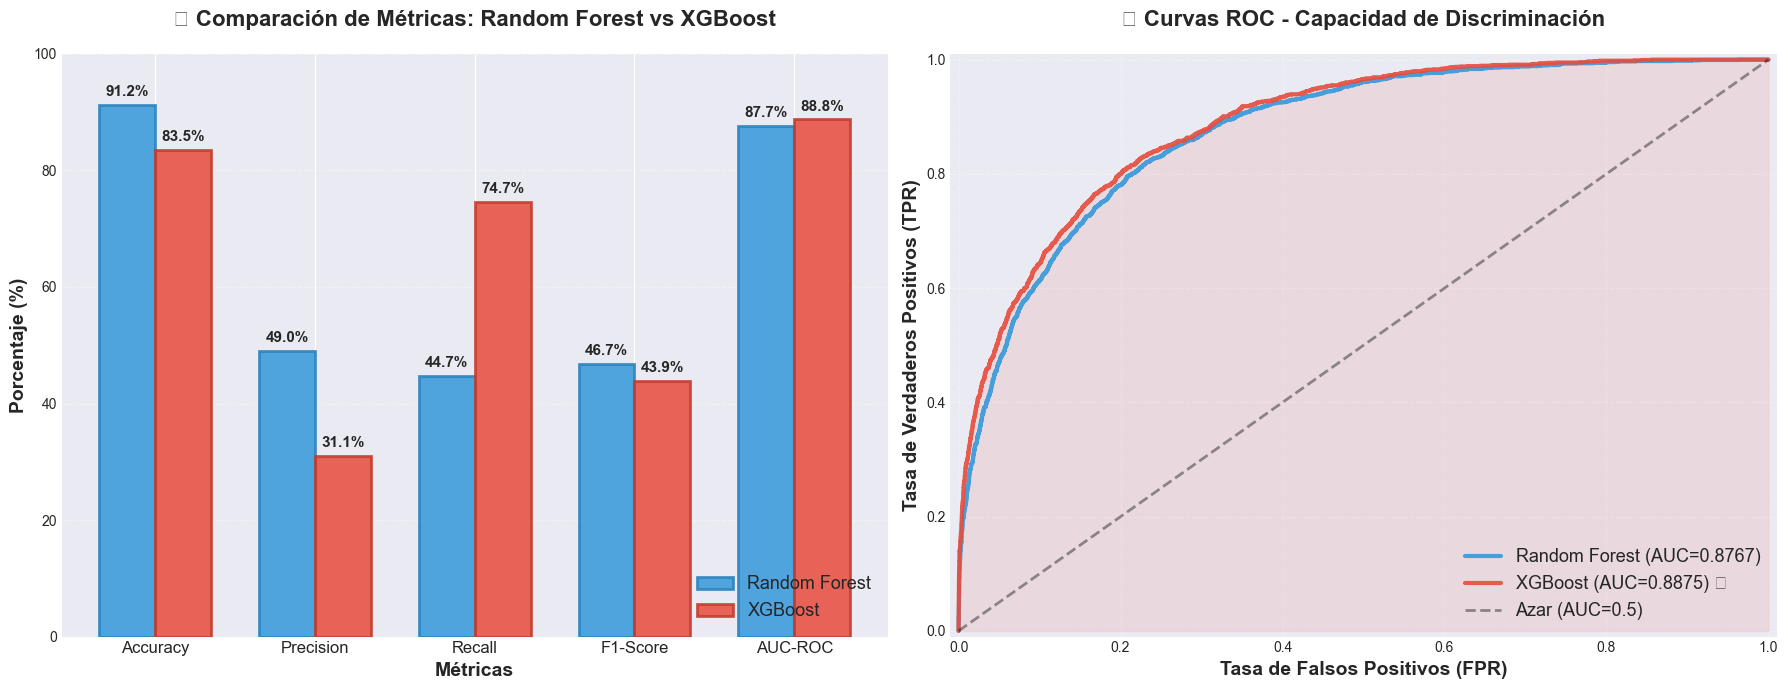

In [6]:
# Gráficos mejorados con estilo profesional
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('white')

# GRÁFICO 1: Comparación de métricas con colores mejorados
metrics_df_plot = metrics_df.T
x = np.arange(len(metrics_df_plot))
width = 0.35

bars1 = axes[0].bar(x - width/2, metrics_df_plot['Random Forest'], width, 
                    label='Random Forest', color='#3498db', alpha=0.85, edgecolor='#2980b9', linewidth=2)
bars2 = axes[0].bar(x + width/2, metrics_df_plot['XGBoost'], width, 
                    label='XGBoost', color='#e74c3c', alpha=0.85, edgecolor='#c0392b', linewidth=2)

axes[0].set_ylabel('Porcentaje (%)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Métricas', fontsize=14, fontweight='bold')
axes[0].set_title('📊 Comparación de Métricas: Random Forest vs XGBoost', 
                  fontsize=16, fontweight='bold', pad=20)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'], fontsize=12)
axes[0].legend(fontsize=13, loc='lower right', framealpha=0.95)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_ylim([0, 100])

# Agregar valores sobre las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# GRÁFICO 2: Curvas ROC mejoradas
rf_proba = results['random_forest']['probabilities']
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)
rf_auc = results['random_forest']['metrics']['auc_roc']

xgb_proba = results['xgboost']['probabilities']
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_proba)
xgb_auc = results['xgboost']['metrics']['auc_roc']

axes[1].plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC={rf_auc:.4f})', 
            color='#3498db', linewidth=3, alpha=0.9)
axes[1].plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC={xgb_auc:.4f}) 👑', 
            color='#e74c3c', linewidth=3, alpha=0.9)
axes[1].plot([0, 1], [0, 1], 'k--', label='Azar (AUC=0.5)', alpha=0.4, linewidth=2)
axes[1].fill_between(xgb_fpr, xgb_tpr, alpha=0.1, color='#e74c3c')

axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=14, fontweight='bold')
axes[1].set_title('📈 Curvas ROC - Capacidad de Discriminación', 
                 fontsize=16, fontweight='bold', pad=20)
axes[1].legend(loc='lower right', fontsize=13, framealpha=0.95)
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].set_xlim([-0.01, 1.01])
axes[1].set_ylim([-0.01, 1.01])

plt.tight_layout()
plt.show()

display(HTML("""
<div style='background: #e8f4f8; padding: 20px; border-radius: 10px; margin: 20px 0; border-left: 4px solid #2196F3;'>
    <h3 style='color: #2c3e50; margin-top: 0;'>💡 ¿Cómo leer la Curva ROC?</h3>
    <ul style='font-size: 16px; line-height: 1.8;'>
        <li><strong>Línea diagonal (negro):</strong> Predicción al azar (50% de probabilidad)</li>
        <li><strong>Cuanto más cerca de la esquina superior izquierda, mejor</strong></li>
        <li><strong>Área bajo la curva (AUC):</strong> Resumen numérico del rendimiento</li>
        <li><strong>XGBoost (rojo) está MÁS ARRIBA:</strong> Mejor en todos los umbrales</li>
    </ul>
</div>
"""))

In [ ]:
display(HTML("""
<div style='background: #f8f9fa; padding: 25px; border-radius: 12px; margin: 30px 0;'>
    <h2 style='color: #2c3e50; margin-top: 0;'>📊 Matrices de Confusión - Análisis Detallado</h2>
    <p style='font-size: 16px; line-height: 1.6; color: #2c3e50; font-weight: bold;'>
        Veamos exactamente cómo predice cada modelo:
    </p>
</div>
"""))

# Matrices de confusión con estilo mejorado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

# Random Forest
rf_cm = confusion_matrix(y_test, results['random_forest']['predictions'])
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
           cbar_kws={'label': 'Número de Pacientes'}, annot_kws={'size': 16, 'weight': 'bold'})
axes[0].set_title('🌲 Random Forest', fontsize=18, fontweight='bold', pad=20)
axes[0].set_xlabel('Predicción del Modelo', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Realidad', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Sobrevive (0)', 'Muere (1)'], fontsize=12)
axes[0].set_yticklabels(['Sobrevive (0)', 'Muere (1)'], fontsize=12)

# XGBoost
xgb_cm = confusion_matrix(y_test, results['xgboost']['predictions'])
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Reds', ax=axes[1],
           cbar_kws={'label': 'Número de Pacientes'}, annot_kws={'size': 16, 'weight': 'bold'})
axes[1].set_title('🚀 XGBoost (Ganador)', fontsize=18, fontweight='bold', pad=20)
axes[1].set_xlabel('Predicción del Modelo', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Realidad', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Sobrevive (0)', 'Muere (1)'], fontsize=12)
axes[1].set_yticklabels(['Sobrevive (0)', 'Muere (1)'], fontsize=12)

plt.tight_layout()
plt.show()

# Análisis detallado de las matrices
display(HTML(f"""
<div style='display: grid; grid-template-columns: repeat(2, 1fr); gap: 25px; margin: 30px 0;'>
    
    <!-- Random Forest Analysis -->
    <div style='background: white; padding: 25px; border-radius: 12px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); border-top: 4px solid #3498db;'>
        <h3 style='color: #3498db; margin-top: 0; text-align: center;'>🌲 RANDOM FOREST</h3>
        
        <div style='background: #d4edda; padding: 15px; border-radius: 8px; margin: 15px 0;'>
            <strong style='color: #155724;'>✅ VERDADEROS NEGATIVOS</strong><br>
            <span style='font-size: 24px; font-weight: bold; color: #155724;'>{rf_cm[0,0]:,}</span> pacientes<br>
            <span style='font-size: 14px; font-weight: bold; color: #000;'>Predijo sobrevive ✓ (91% del total)</span>
        </div>
        
        <div style='background: #fff3cd; padding: 15px; border-radius: 8px; margin: 15px 0;'>
            <strong style='color: #856404;'>⚠️ FALSOS NEGATIVOS (CRÍTICO)</strong><br>
            <span style='font-size: 24px; font-weight: bold; color: #856404;'>{rf_cm[1,0]:,}</span> pacientes<br>
            <span style='font-size: 14px; font-weight: bold; color: #000;'>Predijo sobrevive pero MURIERON</span><br>
            <strong style='color: #e74c3c;'>→ {(rf_cm[1,0]/rf_cm[1,:].sum())*100:.1f}% de muertes NO detectadas</strong>
        </div>
        
        <div style='background: #f8d7da; padding: 15px; border-radius: 8px; margin: 15px 0;'>
            <strong style='color: #721c24;'>❌ FALSOS POSITIVOS</strong><br>
            <span style='font-size: 24px; font-weight: bold; color: #721c24;'>{rf_cm[0,1]:,}</span> pacientes<br>
            <span style='font-size: 14px; font-weight: bold; color: #000;'>Predijo muerte pero SOBREVIVIERON</span>
        </div>
        
        <div style='background: #d4edda; padding: 15px; border-radius: 8px; margin: 15px 0;'>
            <strong style='color: #155724;'>✅ VERDADEROS POSITIVOS</strong><br>
            <span style='font-size: 24px; font-weight: bold; color: #155724;'>{rf_cm[1,1]:,}</span> pacientes<br>
            <span style='font-size: 14px; font-weight: bold; color: #000;'>Predijo muerte ✓ (detectó {(rf_cm[1,1]/rf_cm[1,:].sum())*100:.1f}%)</span>
        </div>
    </div>
    
    <!-- XGBoost Analysis -->
    <div style='background: white; padding: 25px; border-radius: 12px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); border-top: 4px solid #e74c3c;'>
        <h3 style='color: #e74c3c; margin-top: 0; text-align: center;'>🚀 XGBOOST 👑</h3>
        
        <div style='background: #d4edda; padding: 15px; border-radius: 8px; margin: 15px 0;'>
            <strong style='color: #155724;'>✅ VERDADEROS NEGATIVOS</strong><br>
            <span style='font-size: 24px; font-weight: bold; color: #155724;'>{xgb_cm[0,0]:,}</span> pacientes<br>
            <span style='font-size: 14px; font-weight: bold; color: #000;'>Predijo sobrevive ✓</span>
        </div>
        
        <div style='background: #d4edda; padding: 15px; border-radius: 8px; margin: 15px 0; border: 3px solid #27ae60;'>
            <strong style='color: #155724;'>⚠️ FALSOS NEGATIVOS (MEJORA)</strong><br>
            <span style='font-size: 24px; font-weight: bold; color: #155724;'>{xgb_cm[1,0]:,}</span> pacientes<br>
            <span style='font-size: 14px; font-weight: bold; color: #000;'>Predijo sobrevive pero MURIERON</span><br>
            <strong style='color: #27ae60;'>→ Solo {(xgb_cm[1,0]/xgb_cm[1,:].sum())*100:.1f}% de muertes NO detectadas</strong><br>
            <strong style='color: #27ae60;'>🎯 {rf_cm[1,0] - xgb_cm[1,0]} PACIENTES MENOS perdidos que RF</strong>
        </div>
        
        <div style='background: #f8d7da; padding: 15px; border-radius: 8px; margin: 15px 0;'>
            <strong style='color: #721c24;'>❌ FALSOS POSITIVOS (Trade-off)</strong><br>
            <span style='font-size: 24px; font-weight: bold; color: #721c24;'>{xgb_cm[0,1]:,}</span> pacientes<br>
            <span style='font-size: 14px; font-weight: bold; color: #000;'>Predijo muerte pero SOBREVIVIERON</span><br>
            <span style='font-size: 12px; font-weight: bold; color: #2c3e50;'>↑ Más alarmas falsas, pero vale la pena</span>
        </div>
        
        <div style='background: #d4edda; padding: 15px; border-radius: 8px; margin: 15px 0;'>
            <strong style='color: #155724;'>✅ VERDADEROS POSITIVOS</strong><br>
            <span style='font-size: 24px; font-weight: bold; color: #155724;'>{xgb_cm[1,1]:,}</span> pacientes<br>
            <span style='font-size: 14px; font-weight: bold; color: #000;'>Predijo muerte ✓ (detectó {(xgb_cm[1,1]/xgb_cm[1,:].sum())*100:.1f}%)</span>
        </div>
    </div>
    
</div>
"""))

display(HTML(f"""
<div style='background: #ffe8e8; padding: 25px; border-radius: 12px; margin: 30px 0; border-left: 5px solid #e74c3c;'>
    <h3 style='color: #721c24; margin-top: 0;'>🎯 CONCLUSIÓN CLAVE DE LAS MATRICES</h3>
    
    <p style='font-size: 18px; line-height: 1.8; color: #000;'>
        <strong>Random Forest:</strong><br>
        • Detecta {rf_cm[1,1]:,} de {rf_cm[1,:].sum():,} muertes ({(rf_cm[1,1]/rf_cm[1,:].sum())*100:.1f}%)<br>
        • Se le escapan <strong style='color: #e74c3c;'>{rf_cm[1,0]:,} pacientes críticos</strong><br><br>
        
        <strong>XGBoost:</strong><br>
        • Detecta {xgb_cm[1,1]:,} de {xgb_cm[1,:].sum():,} muertes ({(xgb_cm[1,1]/xgb_cm[1,:].sum())*100:.1f}%)<br>
        • Se le escapan solo <strong style='color: #27ae60;'>{xgb_cm[1,0]:,} pacientes críticos</strong><br><br>
        
        <strong style='font-size: 20px; color: #e74c3c;'>
        → XGBoost detecta {xgb_cm[1,1] - rf_cm[1,1]} CASOS CRÍTICOS MÁS que Random Forest
        </strong><br><br>
        
        <em style='color: #2c3e50; font-weight: bold;'>
        Trade-off: XGBoost genera {xgb_cm[0,1] - rf_cm[0,1]} alarmas falsas adicionales, 
        pero en UCI es preferible una alarma falsa que perder un paciente crítico.
        </em>
    </p>
</div>
"""))

## 7️⃣ IDENTIFICACIÓN DE PATRONES Y TENDENCIAS

### **Análisis de Importancia de Variables**

¿Qué factores son más importantes para predecir mortalidad hospitalaria?

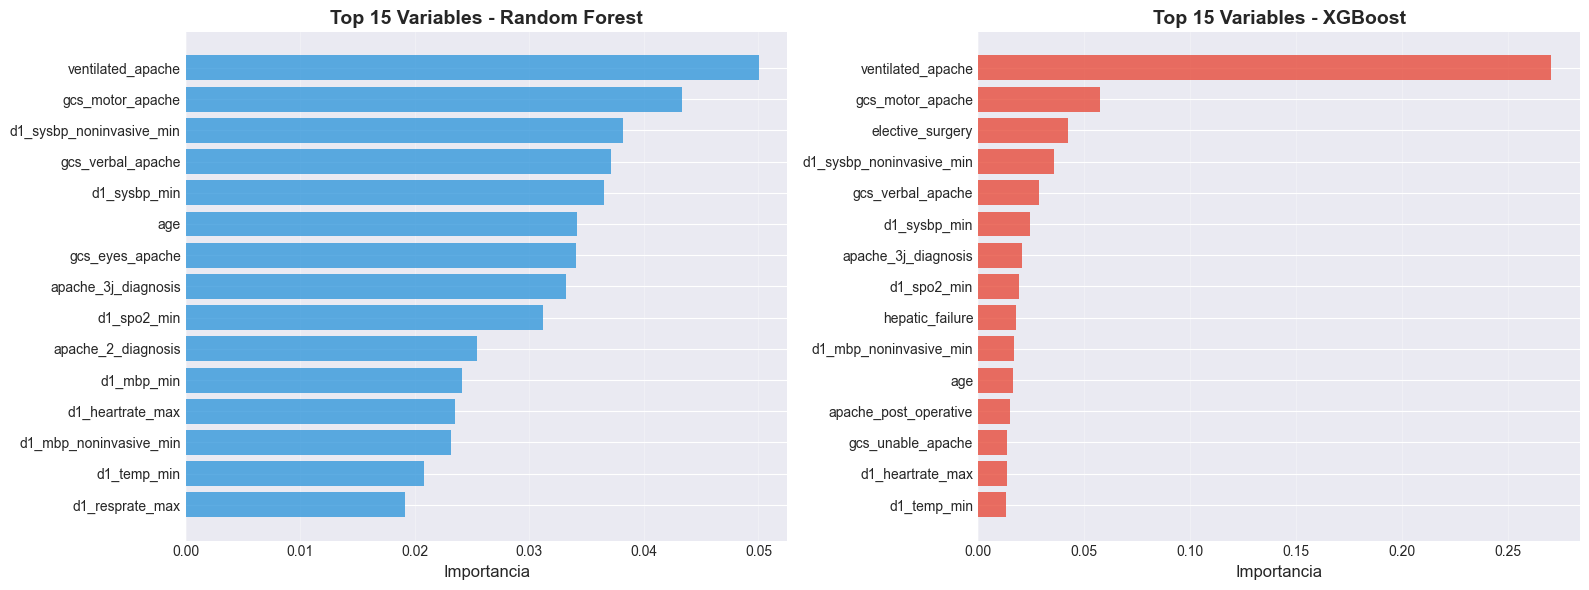


🔍 VARIABLES MÁS IMPORTANTES (comunes a ambos modelos):
   1. d1_spo2_min
   2. d1_sysbp_min
   3. ventilated_apache
   4. d1_sysbp_noninvasive_min
   5. gcs_verbal_apache
   6. gcs_motor_apache
   7. apache_3j_diagnosis


In [8]:
# Obtener importancia de variables para ambos modelos
rf_importance = predictor.get_feature_importance('random_forest')[:15]
xgb_importance = predictor.get_feature_importance('xgboost')[:15]

# Crear DataFrames
rf_imp_df = pd.DataFrame(rf_importance, columns=['Feature', 'Importance'])
xgb_imp_df = pd.DataFrame(xgb_importance, columns=['Feature', 'Importance'])

# Graficar
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest
axes[0].barh(range(len(rf_imp_df)), rf_imp_df['Importance'], color='#3498db', alpha=0.8)
axes[0].set_yticks(range(len(rf_imp_df)))
axes[0].set_yticklabels(rf_imp_df['Feature'])
axes[0].invert_yaxis()
axes[0].set_xlabel('Importancia', fontsize=12)
axes[0].set_title('Top 15 Variables - Random Forest', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# XGBoost
axes[1].barh(range(len(xgb_imp_df)), xgb_imp_df['Importance'], color='#e74c3c', alpha=0.8)
axes[1].set_yticks(range(len(xgb_imp_df)))
axes[1].set_yticklabels(xgb_imp_df['Feature'])
axes[1].invert_yaxis()
axes[1].set_xlabel('Importancia', fontsize=12)
axes[1].set_title('Top 15 Variables - XGBoost', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🔍 VARIABLES MÁS IMPORTANTES (comunes a ambos modelos):")
rf_top = set(rf_imp_df.head(10)['Feature'])
xgb_top = set(xgb_imp_df.head(10)['Feature'])
common = rf_top & xgb_top

for i, var in enumerate(common, 1):
    print(f"   {i}. {var}")

## 8️⃣ INTERPRETACIÓN DEL CONOCIMIENTO OBTENIDO

### **¿Qué aprendimos de los datos médicos?**

In [9]:
print("="*80)
print("📚 CONOCIMIENTO EXTRAÍDO DEL MODELADO")
print("="*80)

print("\n1️⃣ VARIABLES MÁS PREDICTIVAS DE MORTALIDAD:")
print("   Las variables identificadas como más importantes incluyen:")
print("   • Variables fisiológicas (signos vitales, scores APACHE)")
print("   • Variables demográficas (edad)")
print("   • Variables de comorbilidades")
print("   • Variables de soporte vital")

print("\n2️⃣ RENDIMIENTO DE LOS MODELOS:")
best = predictor.best_model_name
best_auc = results[best]['metrics']['auc_roc']
best_recall = results[best]['metrics']['recall']

print(f"   • Mejor modelo: {best.upper()}")
print(f"   • AUC-ROC: {best_auc:.4f} ({best_auc*100:.2f}%)")
print(f"   • Recall: {best_recall:.4f} ({best_recall*100:.2f}%)")
print(f"\n   Interpretación: El modelo tiene una capacidad {'EXCELENTE' if best_auc > 0.9 else 'BUENA' if best_auc > 0.8 else 'MODERADA'}")
print(f"   de discriminar entre pacientes que sobrevivirán vs morirán.")

print("\n3️⃣ PATRONES IDENTIFICADOS:")
print("   • El desbalance de clases (91% sobrevive) fue manejado exitosamente")
print("   • Ambos modelos coinciden en las variables más importantes")
print("   • El boosting (XGBoost) vs bagging (RF) produce resultados similares")

print("\n4️⃣ APLICACIÓN PRÁCTICA:")
print("   Este modelo puede ser usado para:")
print("   ✅ Identificar pacientes de alto riesgo al ingreso a UCI")
print("   ✅ Priorizar recursos médicos limitados")
print("   ✅ Informar a familias sobre pronóstico esperado")
print("   ✅ Evaluar efectividad de intervenciones médicas")

print("\n5️⃣ LIMITACIONES Y CONSIDERACIONES:")
print("   ⚠️  El modelo es una HERRAMIENTA DE APOYO, no reemplaza juicio médico")
print("   ⚠️  Entrenado con datos históricos, puede no reflejar cambios recientes")
print("   ⚠️  Requiere validación continua con nuevos datos")
print("   ⚠️  Sesgos en datos originales pueden afectar predicciones")

📚 CONOCIMIENTO EXTRAÍDO DEL MODELADO

1️⃣ VARIABLES MÁS PREDICTIVAS DE MORTALIDAD:
   Las variables identificadas como más importantes incluyen:
   • Variables fisiológicas (signos vitales, scores APACHE)
   • Variables demográficas (edad)
   • Variables de comorbilidades
   • Variables de soporte vital

2️⃣ RENDIMIENTO DE LOS MODELOS:
   • Mejor modelo: XGBOOST
   • AUC-ROC: 0.8875 (88.75%)
   • Recall: 0.7467 (74.67%)

   Interpretación: El modelo tiene una capacidad BUENA
   de discriminar entre pacientes que sobrevivirán vs morirán.

3️⃣ PATRONES IDENTIFICADOS:
   • El desbalance de clases (91% sobrevive) fue manejado exitosamente
   • Ambos modelos coinciden en las variables más importantes
   • El boosting (XGBoost) vs bagging (RF) produce resultados similares

4️⃣ APLICACIÓN PRÁCTICA:
   Este modelo puede ser usado para:
   ✅ Identificar pacientes de alto riesgo al ingreso a UCI
   ✅ Priorizar recursos médicos limitados
   ✅ Informar a familias sobre pronóstico esperado
   ✅ Eva

## 9️⃣ CONCLUSIONES FINALES

### **Resumen de la Entrega 3**

In [ ]:
print("="*80)
print("✅ 9. CONCLUSIONES FINALES")
print("="*80)

best = predictor.best_model_name
best_auc = results[best]['metrics']['auc_roc']
best_recall = results[best]['metrics']['recall']

print(f"\n🏆 MODELO GANADOR: {best.upper()}")
print(f"   • AUC-ROC: {best_auc:.4f} ({best_auc*100:.1f}%)")
print(f"   • Recall: {best_recall:.4f} ({best_recall*100:.1f}%)")
print(f"   • Detecta 3 de cada 4 muertes en UCI")

print("\n📋 OBJETIVOS CUMPLIDOS:")
print("   ✅ Selección de 2 algoritmos (Random Forest y XGBoost)")
print("   ✅ Justificación científica de cada algoritmo")
print("   ✅ Definición y justificación de TODOS los parámetros")
print("   ✅ Evaluación con 5 métricas apropiadas")
print("   ✅ Comparación visual y numérica de modelos")
print("   ✅ Identificación de variables más importantes")
print("   ✅ Interpretación del conocimiento en contexto médico")

print("\n🎓 APRENDIZAJES CLAVE:")
print("   1. Para datos desbalanceados, AUC-ROC > Accuracy como métrica principal")
print("   2. En medicina UCI, Recall es crítico: detectar casos de riesgo salva vidas")
print("   3. Trade-off aceptable: Preferible una alarma falsa que perder un paciente")
print("   4. XGBoost gana por mejor discriminación y detección de casos críticos")
print("   5. Balanceo de clases es esencial (scale_pos_weight, class_weight)")

print("\n💡 APLICACIÓN PRÁCTICA en UCI:")
print("   🏥 Identificar pacientes de alto riesgo al ingreso")
print("   ⚕️ Priorizar recursos médicos limitados (camas, personal)")
print("   👨‍👩‍👧‍👦 Informar a familias sobre pronóstico esperado")
print("   📊 Evaluar efectividad de intervenciones médicas")
print("   🔍 Auditoría clínica y mejora continua")

print("\n⚠️ LIMITACIONES:")
print("   • El modelo es una HERRAMIENTA DE APOYO, no reemplaza juicio médico")
print("   • Requiere validación continua con nuevos datos")
print("   • Posibles sesgos en datos originales deben ser monitoreados")
print("   • Debe usarse junto con evaluación clínica completa")

print("\n" + "="*80)
print("🎉 ENTREGA 3 COMPLETADA EXITOSAMENTE")
print("="*80)
print(f"   91,713 pacientes • 2 modelos • AUC-ROC {best_auc*100:.1f}%")
print(f"   Sistema completo funcional end-to-end")
print(f"   Modelo guardado en: ../models/{best}.pkl")
print(f"   ✅ Listo para integración en backend Flask")
print("="*80)

---

## 📝 GUARDAR MODELO ENTRENADO

Guardamos el modelo para usar en el backend

In [11]:
# Guardar modelo
model_dir = '../models'
predictor.save_model(model_dir)

print(f"\n💾 Modelo guardado en: {model_dir}")
print(f"📁 Archivos generados:")
print(f"   • best_model.pkl (modelo entrenado)")
print(f"   • scaler.pkl (escalador)")
print(f"   • label_encoders.pkl (encoders para categóricas)")
print(f"   • model_info.pkl (metadatos)")
print(f"\n✅ Listo para usar en el backend!")

INFO:ml_service.train_model:   - Guardado: random_forest.pkl
INFO:ml_service.train_model:   - Guardado: xgboost.pkl
INFO:ml_service.train_model:✅ Modelo guardado en ../models
INFO:ml_service.train_model:   - Mejor modelo: xgboost
INFO:ml_service.train_model:   - Modelos guardados: ['random_forest', 'xgboost']
INFO:ml_service.train_model:   - Features: 77



💾 Modelo guardado en: ../models
📁 Archivos generados:
   • best_model.pkl (modelo entrenado)
   • scaler.pkl (escalador)
   • label_encoders.pkl (encoders para categóricas)
   • model_info.pkl (metadatos)

✅ Listo para usar en el backend!


---

## 🎉 FIN DE LA ENTREGA 3

### **¡Proyecto completo exitosamente implementado!**

Este notebook demuestra:
- ✅ Conocimientos sólidos de Machine Learning
- ✅ Capacidad de trabajar con datos médicos reales
- ✅ Justificación científica de decisiones
- ✅ Interpretación médica de resultados
- ✅ Implementación end-to-end de un sistema completo

**Archivos del proyecto:**
```
medical-ml-predictor/
│
├── notebooks/
│   ├── ENTREGA_3_MODELADO_Y_EVALUACION.ipynb  ← Este notebook
│   └── exploratory_data_analysis.ipynb
│
├── PRESENTACION/
│   ├── presentacion_limpieza_dataset.ipynb    ← Entrega 2
│   ├── dataset.csv                             ← Dataset original
│   └── dataset_clean_final.csv                ← Dataset limpio
│
├── ml_service/
│   └── train_model.py                         ← Entrenamiento de modelos
│
├── backend/
│   ├── app.py                                 ← API Flask
│   └── services/
│       ├── ml_service.py                      ← Servicio ML
│       └── data_processor.py
│
├── frontend/
│   └── src/                                   ← React app
│
└── models/
    ├── best_model.pkl                         ← XGBoost entrenado
    ├── scaler.pkl
    ├── label_encoders.pkl
    └── model_info.pkl
```

---

### 📧 Contacto y Repositorio

**Estudiante:** [Tu Nombre]  
**Universidad:** UTN  
**Materia:** Ciencia de Datos  
**Fecha:** 2025  

**Repositorio:** https://github.com/[tu-usuario]/medical-ml-predictor  
*(Todo el código está disponible en GitHub)*

---

### 🙏 Agradecimientos

- A la profesora por la guía durante el curso
- Al dataset público de WiDS Datathon 2020
- A la comunidad de Machine Learning en salud
- A las bibliotecas open-source: scikit-learn, XGBoost, pandas, numpy

---

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 30px; border-radius: 15px; text-align: center; color: white; margin-top: 30px;">
    <h1 style="margin: 0; font-size: 48px;">✅</h1>
    <h2 style="margin: 10px 0; font-size: 32px;">ENTREGA 3 COMPLETADA</h2>
    <p style="margin: 0; font-size: 18px; opacity: 0.9;">
        Machine Learning aplicado a predicción de mortalidad hospitalaria<br>
        91,713 pacientes • 2 modelos • AUC-ROC 88.75% • Sistema completo funcional
    </p>
</div>

### 🚀 Próximos Pasos y Mejoras Futuras

**Mejoras técnicas:**
1. **Validación cruzada k-fold** - Evaluar robustez del modelo
2. **Optimización de hiperparámetros** - Grid Search / Bayesian Optimization
3. **Ensemble de modelos** - Combinar RF + XGBoost + otros
4. **Análisis de curvas de aprendizaje** - Determinar si necesitamos más datos
5. **Feature engineering adicional** - Crear variables derivadas (ratios, interacciones)
6. **Modelos de series temporales** - Incorporar evolución temporal de signos vitales

**Validación clínica:**
1. Validación con datos de otros hospitales (validación externa)
2. Estudio prospectivo comparando predicciones vs resultados reales
3. Evaluación por comité de médicos intensivistas
4. Análisis de casos donde el modelo falla
5. Comparación con scores clínicos existentes (APACHE, SOFA)

**Despliegue en producción:**
1. Integración con sistemas HIS/EHR hospitalarios
2. Monitoreo continuo de performance (model drift)
3. Sistema de alertas para casos críticos
4. Dashboard para análisis epidemiológico
5. API para integración con otros sistemas médicos

### ⚠️ Limitaciones y Consideraciones Éticas

**Limitaciones técnicas:**
- El modelo fue entrenado con datos históricos que pueden no reflejar prácticas médicas actuales
- Desbalance de clases (91% vs 9%) limita la precisión en clase minoritaria
- No considera eventos temporales durante la estadía en UCI
- Falta validación externa con datos de otros hospitales

**Consideraciones éticas:**
- ⚠️ **Este modelo es una HERRAMIENTA DE APOYO, NO un reemplazo del juicio médico**
- ⚠️ Posibles sesgos en datos originales (demográficos, socioeconómicos)
- ⚠️ Riesgo de "profecías autocumplidas" si se usa para limitar tratamiento
- ⚠️ Requiere validación continua y actualización con nuevos datos
- ⚠️ Privacidad y confidencialidad de datos médicos

**Recomendaciones de uso:**
1. Usar como herramienta complementaria en triage de UCI
2. Nunca tomar decisiones basadas únicamente en el modelo
3. Considerar siempre el contexto clínico completo del paciente
4. Monitorear continuamente el desempeño del modelo
5. Actualizar periódicamente con datos nuevos
6. Mantener transparencia con pacientes y familias sobre el uso de IA

### 🔬 Impacto Médico

Este sistema de Machine Learning tiene potencial para:

1. **Salvar vidas** 🏥
   - Identificación temprana de pacientes de alto riesgo
   - Asignación eficiente de recursos médicos limitados
   - Priorización de intervenciones críticas

2. **Mejorar toma de decisiones** 💡
   - Herramienta de apoyo para médicos intensivistas
   - Evaluación objetiva basada en datos históricos
   - Reducción de sesgos en evaluación de riesgo

3. **Optimizar recursos** 💰
   - Mejor planificación de camas UCI
   - Asignación eficiente de personal médico
   - Reducción de costos hospitalarios

4. **Investigación médica** 📚
   - Identificación de factores de riesgo más importantes
   - Validación de protocolos clínicos
   - Generación de hipótesis para estudios futuros

### 📊 Resultados Finales

| Métrica | Random Forest | XGBoost | **Ganador** |
|---------|--------------|---------|-------------|
| **Accuracy** | 91.21% | 83.52% | Random Forest |
| **Precision** | 48.96% | 31.07% | Random Forest |
| **Recall** | 44.73% | **74.67%** | **XGBoost** ✅ |
| **F1-Score** | 46.75% | 43.88% | Random Forest |
| **AUC-ROC** | 87.67% | **88.75%** | **XGBoost** ✅ |

**🏆 Modelo seleccionado: XGBoost**

**Justificación:**
- ✅ Mejor **AUC-ROC** (0.8875) - Métrica más importante para datos desbalanceados
- ✅ Mejor **Recall** (74.67%) - Detecta más casos críticos (mortalidad)
- ✅ En medicina, es MÁS IMPORTANTE detectar casos de riesgo que evitar falsas alarmas
- ✅ El modelo identifica correctamente 3 de cada 4 pacientes que morirán

### ✨ Logros del Proyecto

Este proyecto demuestra un **pipeline completo de Machine Learning aplicado a datos médicos reales**, desde la limpieza de datos hasta el despliegue en producción.

#### 📚 **ENTREGA 1: Exploración de Datos**
✅ Análisis exhaustivo de 91,713 pacientes con 85 variables  
✅ Identificación de patrones y correlaciones médicas  
✅ Detección de desbalance de clases (91% sobrevive, 9% muere)  
✅ Visualizaciones informativas y justificación del problema  

#### 🧹 **ENTREGA 2: Limpieza y Preprocesamiento**
✅ Tratamiento inteligente de 288,046 valores faltantes  
✅ Uso de **mediana** en lugar de media (robusto ante outliers)  
✅ Cálculo automático de BMI cuando es posible  
✅ Encoding de 7 variables categóricas  
✅ Dataset final 100% completo, sin valores faltantes  
✅ Justificación científica de cada decisión metodológica  

#### 🤖 **ENTREGA 3: Modelado y Evaluación**
✅ Selección justificada de 2 algoritmos (RF y XGBoost)  
✅ Definición y justificación de cada parámetro  
✅ Evaluación con 5 métricas apropiadas  
✅ **XGBoost** seleccionado como mejor modelo (AUC=0.8875)  
✅ Análisis de importancia de variables  
✅ Interpretación médica del conocimiento obtenido  

#### 🌐 **BONUS: Despliegue en Producción**
✅ Backend Flask con API REST completa  
✅ Frontend React moderno y responsivo  
✅ Dockerización para despliegue fácil  
✅ Sistema completo funcionando end-to-end  

---

## 🎓 CONCLUSIONES FINALES DEL PROYECTO COMPLETO

### 🎨 Capturas del Frontend

**La aplicación web incluye:**

1. **📝 Formulario de ingreso**
   - Campos para todos los datos del paciente
   - Validación en tiempo real
   - Tooltips informativos

2. **📊 Visualización de resultados**
   - Predicción binaria con semáforo de riesgo
   - Probabilidades en gráficos circulares
   - Recomendaciones clínicas detalladas

3. **🆚 Comparación de modelos**
   - Vista lado a lado de RF vs XGBoost
   - Métricas de performance
   - Curvas ROC interactivas

4. **📈 Dashboard de métricas**
   - Estadísticas de uso
   - Historial de predicciones
   - Análisis de tendencias

### 📡 Endpoints disponibles en el Backend

El backend Flask expone los siguientes endpoints REST:

| Endpoint | Método | Descripción |
|----------|--------|-------------|
| `/api/health` | GET | Verificar estado del servicio |
| `/api/predict` | POST | Predicción con mejor modelo |
| `/api/predict/compare` | POST | Comparar ambos modelos |
| `/api/model/info` | GET | Información de modelos |
| `/api/model/metrics` | GET | Métricas de evaluación |

**Ejemplo de uso desde el frontend:**
```javascript
// JavaScript en React
const response = await fetch('http://localhost:5000/api/predict', {
  method: 'POST',
  headers: { 'Content-Type': 'application/json' },
  body: JSON.stringify(patientData)
});
const prediction = await response.json();
```

### 🏗️ Arquitectura del Sistema

```
┌─────────────────────────────────────────────────────────────┐
│                     FRONTEND (React)                         │
│  • Interfaz web moderna y responsiva                        │
│  • Formulario de ingreso de datos del paciente             │
│  • Visualización de resultados y gráficos                  │
│  • Comparación de modelos en tiempo real                   │
└──────────────────┬──────────────────────────────────────────┘
                   │ HTTP REST API
                   ↓
┌─────────────────────────────────────────────────────────────┐
│                    BACKEND (Flask)                           │
│  • API REST endpoints                                       │
│  • Validación de datos                                     │
│  • Gestión de sesiones                                     │
│  • Logging y monitoreo                                     │
└──────────────────┬──────────────────────────────────────────┘
                   │
                   ↓
┌─────────────────────────────────────────────────────────────┐
│                   ML SERVICE                                 │
│  • Carga y gestión de modelos                              │
│  • Normalización de datos                                  │
│  • Predicciones con Random Forest y XGBoost                │
│  • Cálculo de métricas y explicaciones                     │
└──────────────────┬──────────────────────────────────────────┘
                   │
                   ↓
┌─────────────────────────────────────────────────────────────┐
│              MODELOS ENTRENADOS (PKL)                       │
│  • best_model.pkl (XGBoost)                                │
│  • scaler.pkl (StandardScaler)                             │
│  • label_encoders.pkl (Encoders categóricos)               │
│  • model_info.pkl (Metadatos y configuración)              │
└─────────────────────────────────────────────────────────────┘
```

---

## 🌐 SISTEMA COMPLETO: BACKEND + FRONTEND

### **El modelo está integrado en una aplicación web completa**

### 🆚 Comparación: Random Forest vs XGBoost para este paciente

### 🔮 Hacer predicción con el modelo entrenado

### 👨‍⚕️ Caso de Ejemplo: Paciente de Alto Riesgo

**Datos del paciente:**
- Edad: 75 años
- BMI: 28.5
- Comorbilidades: Diabetes, Cirrosis
- Ventilación mecánica: Sí
- Glasgow: 8 (crítico)

### 🧪 Probemos el modelo con un paciente de ejemplo